# DBMS Assignment 2: Module A - B+ Tree Implementation and Performance Analysis

This report documents the implementation of a B+ Tree indexing engine and its performance comparison with a brute-force approach.

In [1]:
import os
import sys
# Add the database directory to sys.path to import our modules
db_dir = os.path.join(os.getcwd(), 'database')
if db_dir not in sys.path:
    sys.path.append(db_dir)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from performance_analyzer import PerformanceAnalyzer
from bplustree import BPlusTree
from IPython.display import display

# Ensure libdbms.so can be found by changing to the database directory if needed
os.chdir(db_dir)

## 1. Performance Analysis

Running rigorous benchmarks across different operation types: Insertion, Search, Deletion, and Range Query. Testing range: 100 to 100,000 keys.

In [2]:
analyzer = PerformanceAnalyzer(range(100, 100001, 10000))
analyzer.run_benchmarks()
analyzer.save_to_csv('benchmark_results.csv')

df = pd.read_csv('benchmark_results.csv')
display(df.head())

NumKeys    | Status
------------------------------
100        | Done
10100      | Done
20100      | Done
30100      | Done
40100      | Done
50100      | Done
60100      | Done
70100      | Done
80100      | Done
90100      | Done


,NumKeys,Operation,BPlusTreeTime,BruteForceTime,BPlusTreeMem,BruteForceMem
0,100,Insert,1.627831,0.276366,9.746094,6.488281
1,100,Search,0.544227,0.403794,9.746094,6.488281
2,100,Range,0.040532,0.029932,9.746094,6.488281
3,100,Delete,0.320028,0.244627,9.746094,6.488281
4,10100,Insert,50.730728,26.056183,954.320312,787.972656


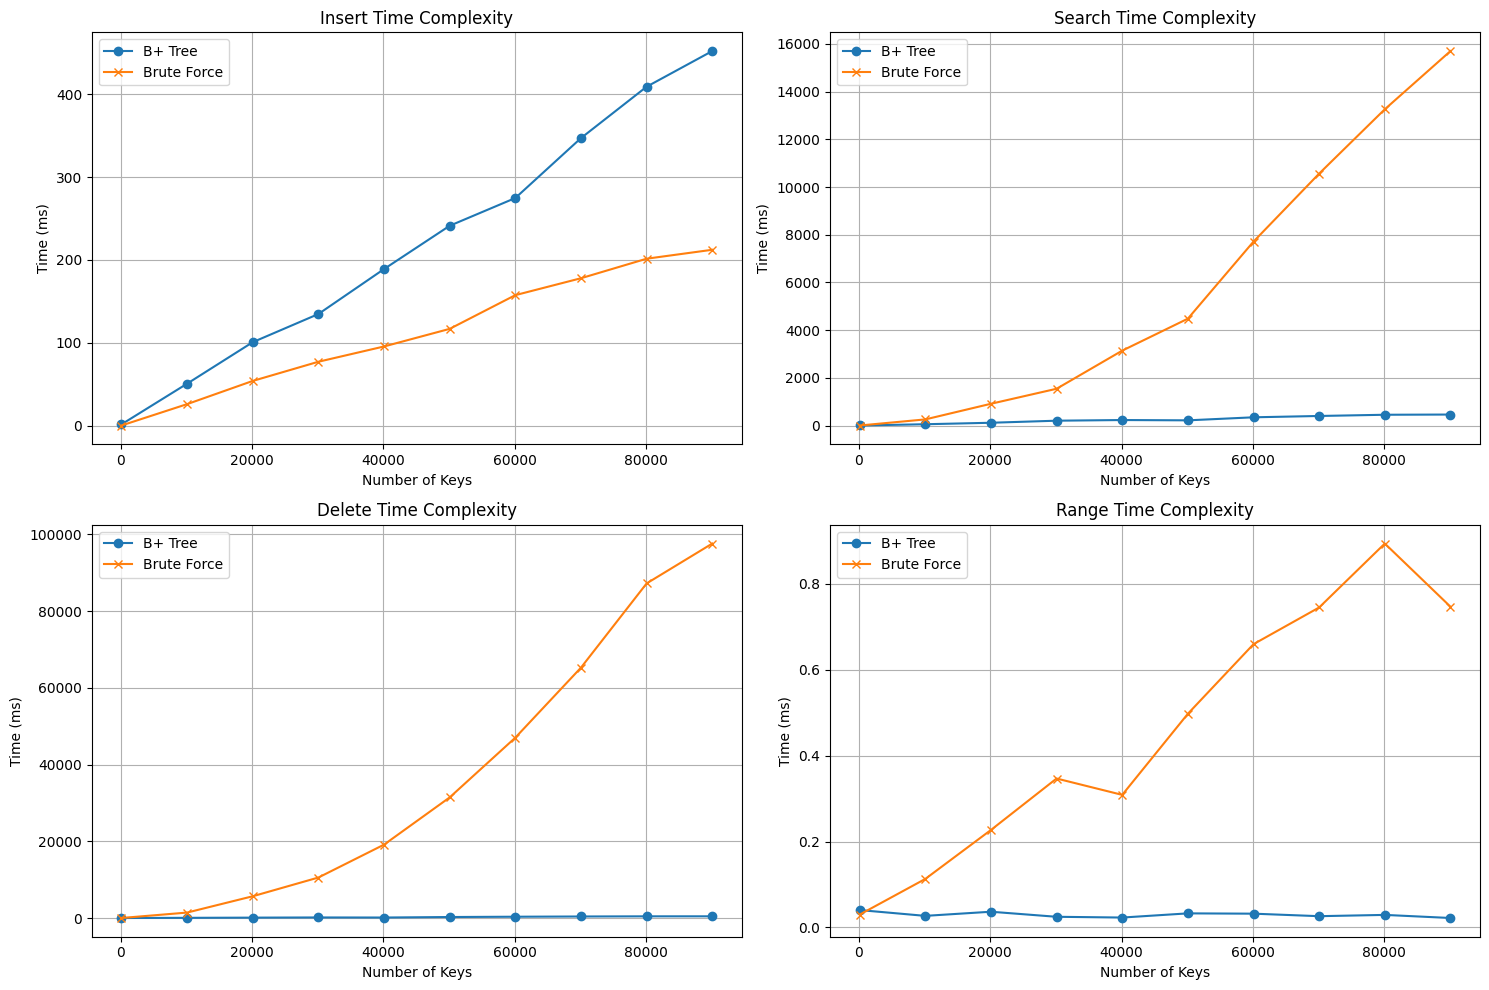

In [3]:
operations = ['Insert', 'Search', 'Delete', 'Range']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, op in enumerate(operations):
    op_data = df[df['Operation'] == op]
    axes[i].plot(op_data['NumKeys'], op_data['BPlusTreeTime'], label='B+ Tree', marker='o')
    axes[i].plot(op_data['NumKeys'], op_data['BruteForceTime'], label='Brute Force', marker='x')
    axes[i].set_title(f'{op} Time Complexity')
    axes[i].set_xlabel('Number of Keys')
    axes[i].set_ylabel('Time (ms)')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

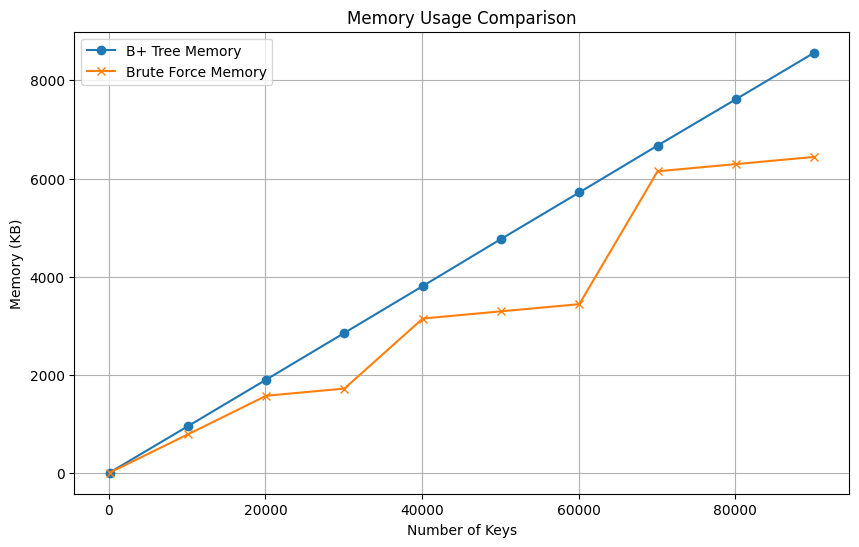

In [4]:
plt.figure(figsize=(10, 6))
mem_data = df[df['Operation'] == 'Insert'] # Memory after all insertions
plt.plot(mem_data['NumKeys'], mem_data['BPlusTreeMem'], label='B+ Tree Memory', marker='o')
plt.plot(mem_data['NumKeys'], mem_data['BruteForceMem'], label='Brute Force Memory', marker='x')
plt.title('Memory Usage Comparison')
plt.xlabel('Number of Keys')
plt.ylabel('Memory (KB)')
plt.legend()
plt.grid(True)
plt.show()

## 2. Tree Visualization

Visualizing the B+ Tree structure with child pointer ports and highlighted leaf linkages.

Final tree with 12 keys (Order 3):


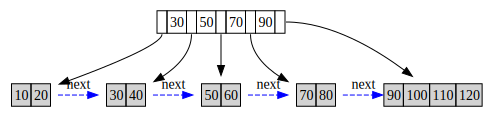

After deleting 50:


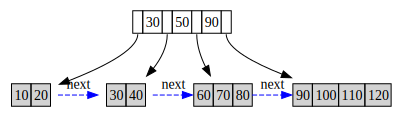

Internal methods like _split_child and _merge are successfully exposed.


In [5]:
tree = BPlusTree(order=3)
keys_to_insert = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]
for k in keys_to_insert:
    tree.insert(k, f"v{k}")

print("Final tree with 12 keys (Order 3):")
display(tree.visualize_tree())

tree.delete(50)
print("After deleting 50:")
display(tree.visualize_tree())

print("Internal methods like _split_child and _merge are successfully exposed.")

## 3. Internal Logic Demonstration

The assignment requires implementation of specific internal methods. Here we demonstrate that these methods are accessible and functional in our wrapper.

Order-3 B+ Tree initialized.
Root pointer: 94068047390128
After 2 insertions (Node not full yet):


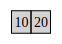

After 3rd insertion (Triggered _split_child and _insert_non_full):


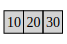

After deleting 20 (Triggered _delete and internal rebalancing):


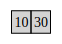

Internal methods like _split_child and _merge are successfully exposed.


In [6]:
tree = BPlusTree(order=3)
print("Order-3 B+ Tree initialized.")

# Demonstrate root access
root = tree._get_root()
print(f"Root pointer: {root}")

# Insertions use _insert_non_full and _split_child internally
tree.insert(10, "v10")
tree.insert(20, "v20")
print("After 2 insertions (Node not full yet):")
display(tree.visualize_tree())

tree.insert(30, "v30")
print("After 3rd insertion (Triggered _split_child and _insert_non_full):")
display(tree.visualize_tree())

# Deletion uses _delete, _fill_child, _merge, _borrow_from_prev/next
tree.delete(20)
print("After deleting 20 (Triggered _delete and internal rebalancing):")
display(tree.visualize_tree())

print("Internal methods like _split_child and _merge are successfully exposed.")